In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from matplotlib.ticker import MultipleLocator

In [7]:
def extract_job_info(job_id,jobs_df,target_metrics):
    job_data = jobs_df[jobs_df['job_rec_id'] == job_id]
    info = {}
    
    for metric in target_metrics:
        metric_data = job_data[job_data['metric'] == metric]
        if not metric_data.empty:
            if metric in ['submit_job', 'job_epilog_complete', 'launch_job']:
                info[metric] = metric_data['t'].iloc[0]
            else:
                info[metric] = metric_data['value'].iloc[0]
        else:
            info[metric] = None
    return info
    
def calculate_metrics(result_dir):
    df = pd.read_csv(result_dir)
    jobs_df = df[df['job_rec_id'].notna()].copy()
    jobs_df['job_rec_id'] = jobs_df['job_rec_id'].astype(int)

    target_metrics = ['job_name', 'job_id','uid', 'launch_job', 'submit_job', 
                      'job_epilog_complete', 'carbon_emissions', 'carbon_emissions_actual']

    job_ids = jobs_df['job_rec_id'].unique()
    job_info_list = [extract_job_info(job_id, jobs_df, target_metrics) for job_id in sorted(job_ids)]
    job_summary = pd.DataFrame(job_info_list)

    job_summary['carbon_emissions_actual'] = pd.to_numeric(job_summary['carbon_emissions_actual'], errors='coerce')
    job_summary['carbon_emissions'] = pd.to_numeric(job_summary['carbon_emissions'], errors='coerce')

    filtered_actual = job_summary[job_summary['carbon_emissions_actual'] < 15]
    filtered_submit = job_summary[job_summary['carbon_emissions'] < 15]

    diff_df = pd.DataFrame({
        'actual': filtered_actual['carbon_emissions_actual'],
        'predicted': filtered_submit['carbon_emissions']
    }).dropna()

    differences = (diff_df['actual'] - diff_df['predicted']).tolist()

    result_metrics = {
        'total_emissions_sum_submit': diff_df['actual'].tolist(),
        'total_emissions_sum': diff_df['predicted'].tolist(),
        'differences': differences
    }

    return result_metrics

In [8]:
# 2024-12-15
ci_dir_5am = "result/ci_new_5am_slurmctld_log.csv"
backfill_dir_5am = "result/backfill_5am_slurmctld_log.csv"
fifo_dir_5am =  "result/fifo_5am_slurmctld_log.csv"
saf_timenorm_dir_5am = "result/saf-time_5am_slurmctld_log.csv"
saf_dir_5am = "result/saf_5am_slurmctld_log.csv"
ci_result_5am = calculate_metrics(ci_dir_5am)
fifo_result_5am = calculate_metrics(fifo_dir_5am)
backfill_result_5am = calculate_metrics(backfill_dir_5am)
saf_timenorm_result_5am = calculate_metrics(saf_timenorm_dir_5am)
saf_result_5am = calculate_metrics(saf_dir_5am)


ci_dir_8am = "result/ci_new_8am_slurmctld_log.csv"
backfill_dir_8am = "result/backfill_8am_slurmctld_log.csv"
fifo_dir_8am =  "result/fifo_8am_slurmctld_log.csv"
saf_timenorm_dir_8am = "result/saf-time_8am_slurmctld_log.csv"
saf_dir_8am = "result/saf_8am_slurmctld_log.csv"
ci_result_8am = calculate_metrics(ci_dir_8am)
fifo_result_8am = calculate_metrics(fifo_dir_8am)
backfill_result_8am = calculate_metrics(backfill_dir_8am)
saf_timenorm_result_8am = calculate_metrics(saf_timenorm_dir_8am)
saf_result_8am = calculate_metrics(saf_dir_8am)


ci_dir_1pm = "result/ci_new_1pm_slurmctld_log.csv"
backfill_dir_1pm = "result/backfill_1pm_slurmctld_log.csv"
fifo_dir_1pm =  "result/fifo_1pm_slurmctld_log.csv"
saf_timenorm_dir_1pm = "result/saf-time_1pm_slurmctld_log.csv"
saf_dir_1pm = "result/saf_1pm_slurmctld_log.csv"
ci_result_1pm = calculate_metrics(ci_dir_1pm)
fifo_result_1pm = calculate_metrics(fifo_dir_1pm)
backfill_result_1pm = calculate_metrics(backfill_dir_1pm)
saf_timenorm_result_1pm = calculate_metrics(saf_timenorm_dir_1pm)
saf_result_1pm = calculate_metrics(saf_dir_1pm)


ci_dir_6pm = "result/ci_new_6pm_slurmctld_log.csv"
backfill_dir_6pm = "result/backfill_6pm_slurmctld_log.csv"
fifo_dir_6pm =  "result/fifo_6pm_slurmctld_log.csv"
saf_timenorm_dir_6pm = "result/saf-time_6pm_slurmctld_log.csv"
saf_dir_6pm = "result/saf_6pm_slurmctld_log.csv"
ci_result_6pm = calculate_metrics(ci_dir_6pm)
fifo_result_6pm = calculate_metrics(fifo_dir_6pm)
backfill_result_6pm = calculate_metrics(backfill_dir_6pm)
saf_timenorm_result_6pm = calculate_metrics(saf_timenorm_dir_6pm)
saf_result_6pm = calculate_metrics(saf_dir_6pm)

In [9]:
data_actual_6pm = [
    ci_result_6pm['total_emissions_sum'],
    fifo_result_6pm['total_emissions_sum'],
    backfill_result_6pm['total_emissions_sum'],
    saf_timenorm_result_6pm['total_emissions_sum'],
    saf_result_6pm['total_emissions_sum']
]

data_actual_1pm = [
    ci_result_1pm['total_emissions_sum'],
    fifo_result_1pm['total_emissions_sum'],
    backfill_result_1pm['total_emissions_sum'],
    saf_timenorm_result_1pm['total_emissions_sum'],
    saf_result_1pm['total_emissions_sum']
]

data_actual_8am = [
    ci_result_8am['total_emissions_sum'],
    fifo_result_8am['total_emissions_sum'],
    backfill_result_8am['total_emissions_sum'],
    saf_timenorm_result_8am['total_emissions_sum'],
    saf_result_8am['total_emissions_sum']
]

data_actual_5am = [
    ci_result_5am['total_emissions_sum'],
    fifo_result_5am['total_emissions_sum'],
    backfill_result_5am['total_emissions_sum'],
    saf_timenorm_result_5am['total_emissions_sum'],
    saf_result_5am['total_emissions_sum']
]

In [11]:
data_differences = {
    "5 AM": [
        ci_result_5am['differences'],
        fifo_result_5am['differences'],
        backfill_result_5am['differences'],
        saf_timenorm_result_5am['differences'],
        saf_result_5am['differences']
    ],
    "8 AM": [
        ci_result_8am['differences'],
        fifo_result_8am['differences'],
        backfill_result_8am['differences'],
        saf_timenorm_result_8am['differences'],
        saf_result_8am['differences']
    ],
    "1 PM": [
        ci_result_1pm['differences'],
        fifo_result_1pm['differences'],
        backfill_result_1pm['differences'],
        saf_timenorm_result_1pm['differences'],
        saf_result_1pm['differences']
    ],
    "6 PM": [
        ci_result_6pm['differences'],
        fifo_result_6pm['differences'],
        backfill_result_6pm['differences'],
        saf_timenorm_result_6pm['differences'],
        saf_result_6pm['differences']
    ]
}


In [32]:
def draw_combined_box_plots(data_dict, save_name, y_title, title):

    labels = ['Carbon-Aware', 'FIFO', 'Backfill', 'SAF-TimeNorm', 'SAF']
    colors = ['dodgerblue','gray','green','purple','orange']

    fig, axes = plt.subplots(2, 2, figsize=(12,10))
    axes = axes.flatten()  
    
    for ax, (time_label, data) in zip(axes, data_dict.items()):
        flierprops = dict(marker='o', markersize=2, alpha=0.6)
        box = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=True, widths=0.6, flierprops=flierprops)

        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        
        ax.set_title(f"{title } ({time_label})")
        ax.set_ylabel(y_title)
        ax.set_xlabel("Algorithms")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        #ax.yaxis.set_major_locator(MultipleLocator(0.5))

        print(f"\n{time_label} Statistics:")
        print("Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   ")
        print("-"*60)
        for label, d in zip(labels, data):
            print(f"{label[:8]:<9} | {np.min(d):>7.2f} | {np.percentile(d,25):>7.2f} | "
                 f"{np.median(d):>7.2f} | {np.percentile(d,75):>7.2f} | {np.max(d):>7.2f}")

    plt.tight_layout()
    
    save_dir = "/Users/amber/slurm_work"
    save_path = os.path.join(save_dir, f"{save_name}.png")
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=True, widths=0.6, flierprops=flierprops)
/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=True, widths=0.6, flierprops=flierprops)
/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_art


5am Statistics:
Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   
------------------------------------------------------------
Carbon-A  |    0.00 |    0.03 |    0.09 |    0.28 |    3.34
FIFO      |    0.00 |    0.03 |    0.10 |    0.28 |    3.34
Backfill  |    0.00 |    0.03 |    0.10 |    0.28 |    3.34
SAF-Time  |    0.00 |    0.03 |    0.10 |    0.28 |    3.34
SAF       |    0.00 |    0.03 |    0.10 |    0.28 |    3.34

8am Statistics:
Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   
------------------------------------------------------------
Carbon-A  |    0.00 |    0.04 |    0.14 |    0.40 |    3.23
FIFO      |    0.00 |    0.04 |    0.15 |    0.40 |    3.23
Backfill  |    0.00 |    0.04 |    0.15 |    0.40 |    3.23
SAF-Time  |    0.00 |    0.04 |    0.15 |    0.40 |    3.23
SAF       |    0.00 |    0.04 |    0.15 |    0.40 |    3.23

1pm Statistics:
Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   
--------------------------------------------

/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=True, widths=0.6, flierprops=flierprops)


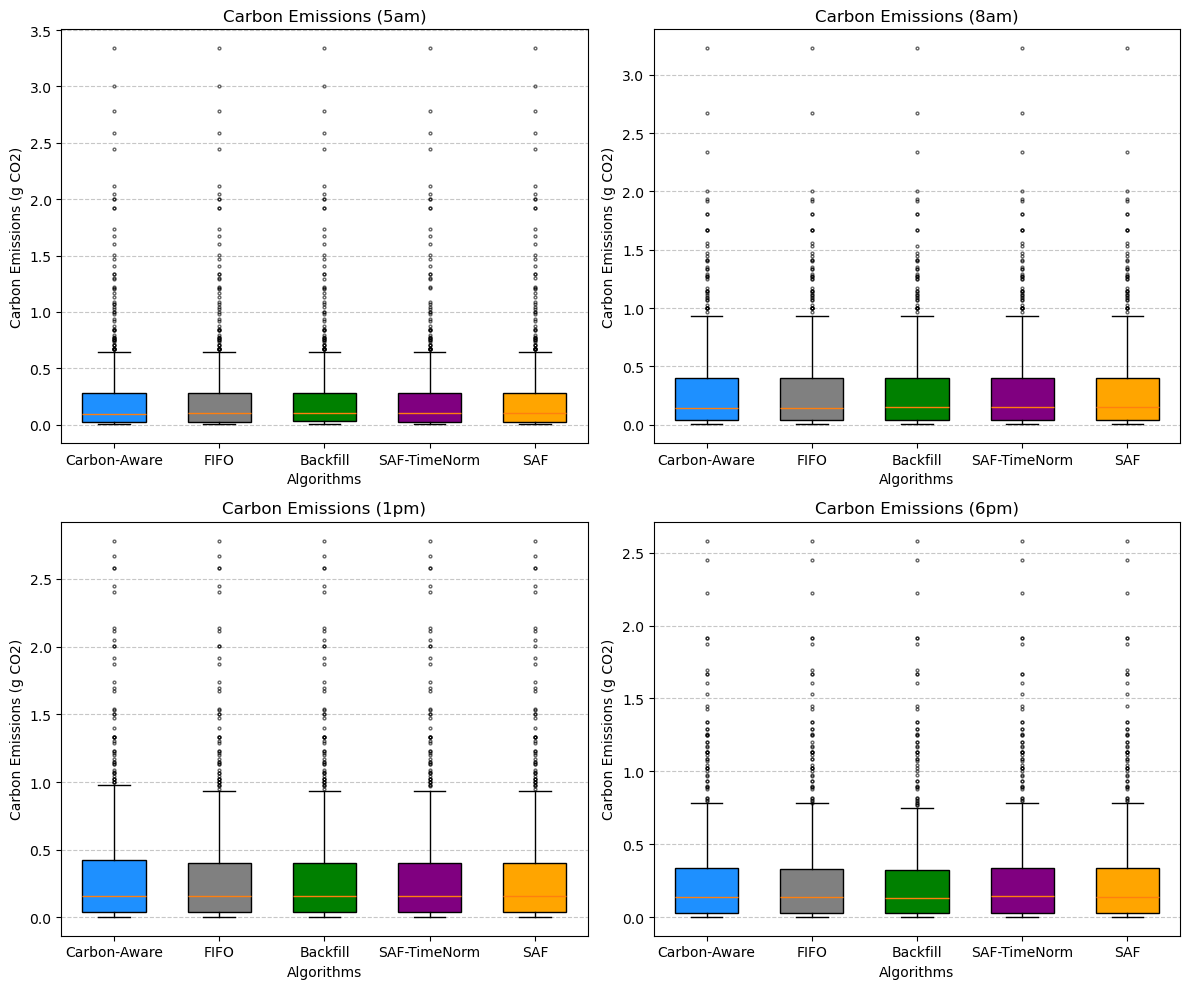

In [35]:
data_actual_emissions = {
    '5am': data_actual_5am,
    '8am': data_actual_8am,
    '1pm': data_actual_1pm,
    '6pm': data_actual_6pm
}

draw_combined_box_plots(data_actual_emissions, "carbon_emissions_box_plot", 'Carbon Emissions (g CO2)', 'Carbon Emissions')

/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=True, widths=0.6, flierprops=flierprops)
/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_artist=True, labels=labels, showfliers=True, widths=0.6, flierprops=flierprops)
/var/folders/dl/x3ssbg515dj0h1p3gsvp9svh0000gn/T/ipykernel_8176/6802370.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, patch_art


5 AM Statistics:
Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   
------------------------------------------------------------
Carbon-A  |   -0.98 |    0.00 |    0.00 |    0.00 |    1.50
FIFO      |   -2.67 |   -0.03 |    0.00 |    0.05 |    1.53
Backfill  |   -1.11 |   -0.01 |    0.00 |    0.03 |    2.58
SAF-Time  |   -1.34 |   -0.02 |    0.00 |    0.01 |    0.84
SAF       |   -2.78 |    0.00 |    0.00 |    0.04 |    0.90

8 AM Statistics:
Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   
------------------------------------------------------------
Carbon-A  |   -0.70 |    0.00 |    0.00 |    0.00 |    1.07
FIFO      |   -1.54 |   -0.05 |    0.00 |    0.00 |    1.07
Backfill  |   -1.07 |   -0.03 |    0.00 |    0.02 |    1.47
SAF-Time  |   -1.02 |   -0.06 |    0.00 |    0.00 |    1.92
SAF       |   -1.94 |   -0.02 |    0.00 |    0.00 |    0.85

1 PM Statistics:
Algorithm |   Min   |   Q1    |  Median |   Q3    |   Max   
-----------------------------------------

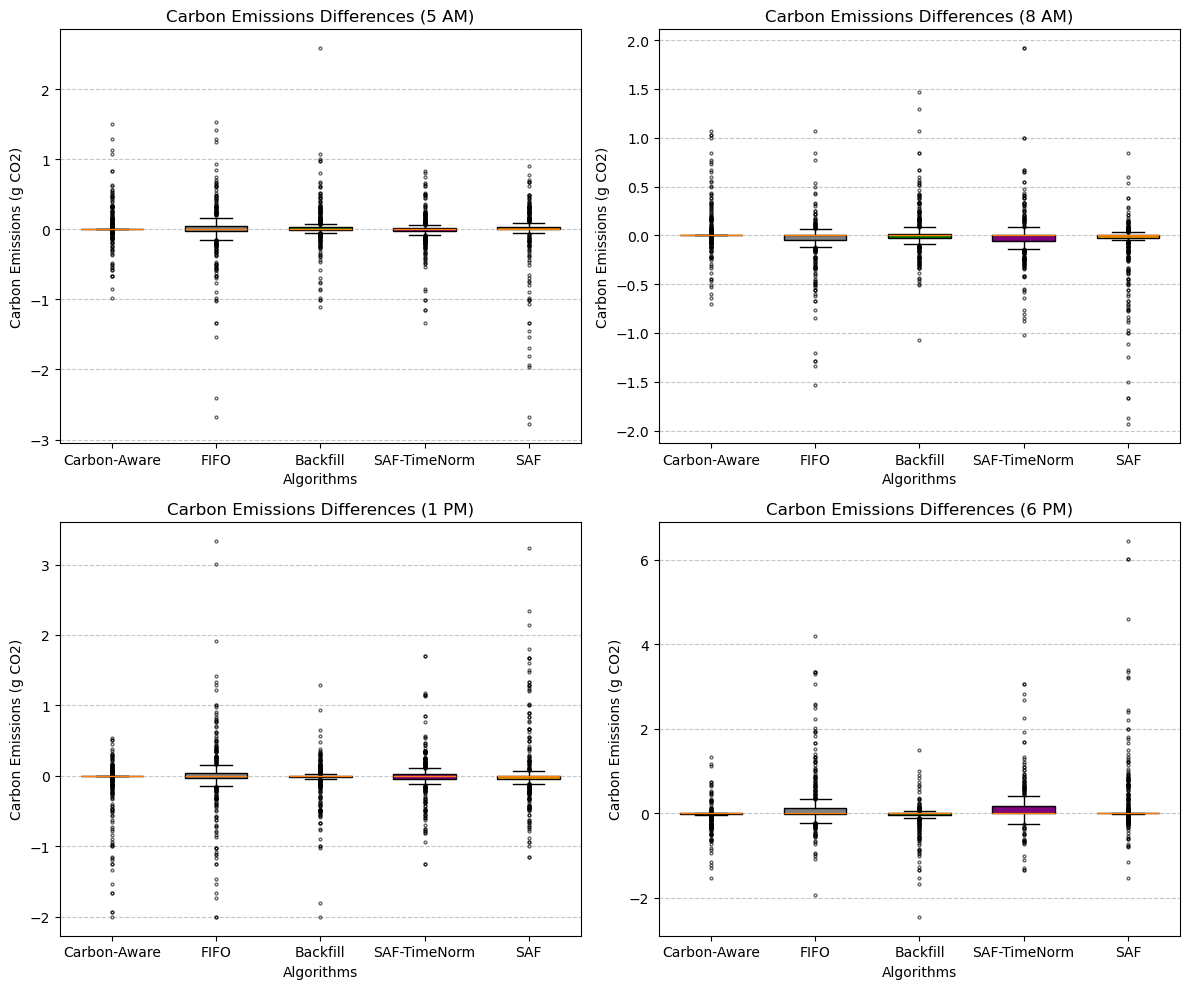

In [36]:
draw_combined_box_plots(data_differences, "carbon_differences_box_plot", 'Carbon Emissions (g CO2)', 'Carbon Emissions Differences')